## 1. 데이터 로드

In [30]:
import pandas as pd
import numpy as np

# 학습 데이터
train_occ  = pd.read_csv("csi_features_occupied.csv")
train_uocc = pd.read_csv("csi_features_unoccupied.csv")
train_df   = pd.concat([train_occ, train_uocc], ignore_index=True)

# 테스트 데이터 (다른 세션)
test_occ  = pd.read_csv("csi_features_occupied_0623.csv")
test_uocc = pd.read_csv("csi_features_unoccupied_plus.csv")
test_df   = pd.concat([test_occ, test_uocc], ignore_index=True)

print(f"학습 — 재실:{len(train_occ)}  공실:{len(train_uocc)}  합계:{len(train_df)}")
print(f"테스트 — 재실:{len(test_occ)}  공실:{len(test_uocc)}  합계:{len(test_df)}")
train_df.head()


학습 — 재실:606  공실:600  합계:1206
테스트 — 재실:71  공실:186  합계:257


,label,rx,start,rssi_mean,rssi_std,amp_mean,amp_std_time,subcarrier_var_mean,subcarrier_std_mean,temporal_diff_mean_abs,...,window_var,spectral_total_power,low_band_ratio,mid_band_ratio,dominant_freq_idx,corr_mean_abs,spectral_entropy,peak_to_peak,skewness,kurtosis
0,occupied,RX2,0,-43.20,0.948683,13.330252,1.375304,11.356703,3.258676,0.421570,...,1.891461,1.891461,0.699357,0.271926,0.031250,0.510913,4.283111,8.242604,-1.678089,4.816867
1,occupied,RX1,0,-52.16,1.254751,12.465112,1.295252,15.845901,3.896587,0.301267,...,1.677677,1.677677,0.729027,0.247488,0.031250,0.402147,4.105193,7.731445,-1.369974,4.529206
2,occupied,RX3,0,-41.45,0.898610,11.464364,0.877445,22.609159,4.627463,0.258771,...,0.769910,0.769910,0.557864,0.405132,0.015625,0.608308,4.935919,5.500643,-2.487304,9.722371
3,occupied,RX2,100,-44.62,1.405560,12.796632,1.071785,10.057989,3.094802,0.361433,...,1.148722,1.148722,0.629066,0.341873,0.007812,0.411852,4.729134,7.026325,-2.188492,7.518004
4,occupied,RX1,100,-50.06,1.515388,12.688499,1.043142,15.469226,3.748480,0.318122,...,1.088146,1.088146,0.545402,0.416283,0.007812,0.420216,4.879763,7.171392,-3.067937,13.058200


## 2. 전처리

In [31]:
def preprocess(df, fit_cols=None):
    df = df.copy()
    df["label_bin"] = (df["label"] == "occupied").astype(int)
    df = pd.get_dummies(df, columns=["rx"], prefix="rx")
    drop_cols = ["label", "start", "label_bin"]
    cols = [c for c in df.columns if c not in drop_cols]
    if fit_cols is not None:
        for c in fit_cols:
            if c not in df.columns:
                df[c] = 0.0
        cols = fit_cols
    return df[cols].astype(float), df["label_bin"], cols

X_train, y_train, feature_cols = preprocess(train_df)
X_test,  y_test,  _            = preprocess(test_df, fit_cols=feature_cols)

print(f"피처 수: {len(feature_cols)}")
print(f"학습 재실={y_train.sum()}  공실={len(y_train)-y_train.sum()}")
print(f"테스트 재실={y_test.sum()}  공실={len(y_test)-y_test.sum()}")


피처 수: 21
학습 재실=606  공실=600
테스트 재실=71  공실=186


## 3. 피처 분포 비교

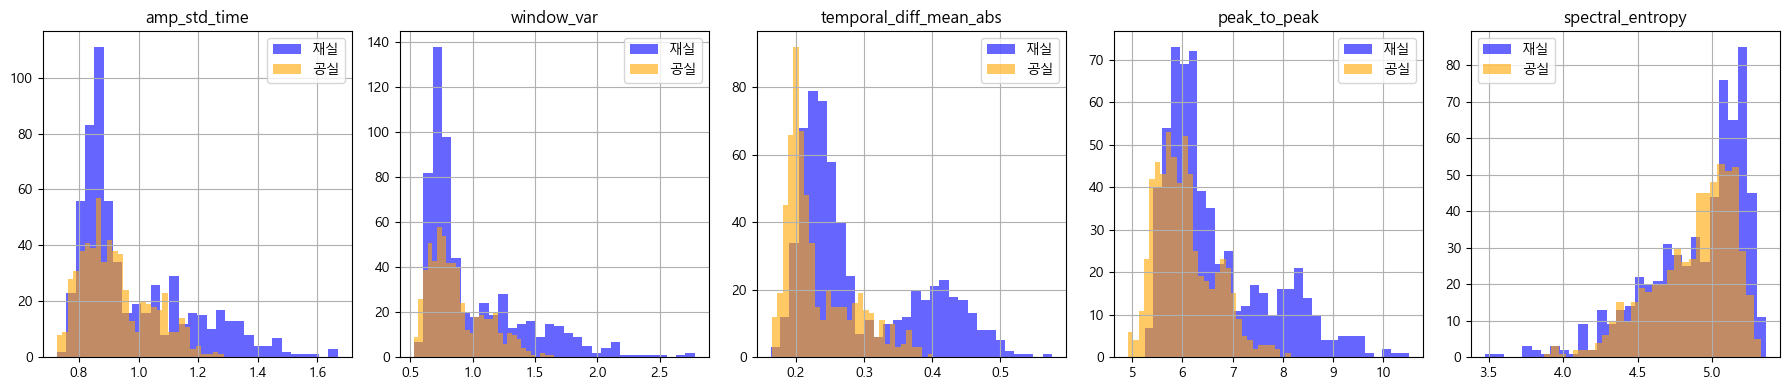

In [32]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

key_feats = ["amp_std_time", "window_var", "temporal_diff_mean_abs", "peak_to_peak", "spectral_entropy"]
fig, axes = plt.subplots(1, len(key_feats), figsize=(18, 4))

for ax, feat in zip(axes, key_feats):
    df[df["label_bin"]==1][feat].hist(ax=ax, alpha=0.6, label="재실", bins=30, color="blue")
    df[df["label_bin"]==0][feat].hist(ax=ax, alpha=0.6, label="공실", bins=30, color="orange")
    ax.set_title(feat)
    ax.legend()

plt.tight_layout()
plt.savefig("eda_boxplot.png", dpi=100)
plt.show()


## 4. 모델 비교 (5-Fold CV)

In [33]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

candidates = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2,
        class_weight="balanced", random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=10, gamma="scale",
                    probability=True, class_weight="balanced", random_state=42)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in candidates.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    results[name] = scores
    print(f"{name:20s}  F1={scores.mean():.4f} +- {scores.std():.4f}")


RandomForest          F1=0.9983 +- 0.0020
GradientBoosting      F1=0.9951 +- 0.0048
SVM                   F1=0.9958 +- 0.0053


## 5. 최고 모델 선택 + 확률 보정

=== 테스트셋 성능 (다른 세션) ===
              precision    recall  f1-score   support

          공실       0.99      0.78      0.88       186
          재실       0.64      0.99      0.77        71

    accuracy                           0.84       257
   macro avg       0.81      0.89      0.83       257
weighted avg       0.89      0.84      0.85       257

보정 전: [0.784 1.    0.135 0.786 0.991 1.    0.984 0.991 0.985 0.958]
보정 후: [0.961 1.    0.    0.999 1.    1.    1.    1.    1.    1.   ]


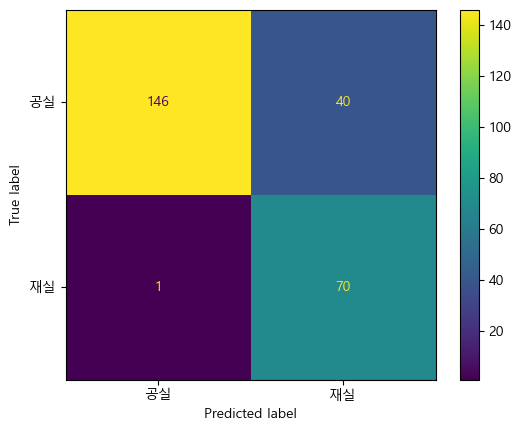

In [34]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

raw_model = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    class_weight="balanced", random_state=42, n_jobs=-1
)

calibrated_model = CalibratedClassifierCV(raw_model, method="isotonic", cv=5)
calibrated_model.fit(X_train, y_train)

# 테스트셋 평가 (다른 세션 — 실제 정확도)
print("=== 테스트셋 성능 (다른 세션) ===")
y_pred = calibrated_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["공실", "재실"]))

# 보정 전후 신뢰도 비교
raw_model.fit(X_train, y_train)
sample = X_test.iloc[:10]
print("보정 전:", raw_model.predict_proba(sample)[:, 1].round(3))
print("보정 후:", calibrated_model.predict_proba(sample)[:, 1].round(3))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["공실", "재실"]).plot()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()


## 6. 피처 중요도

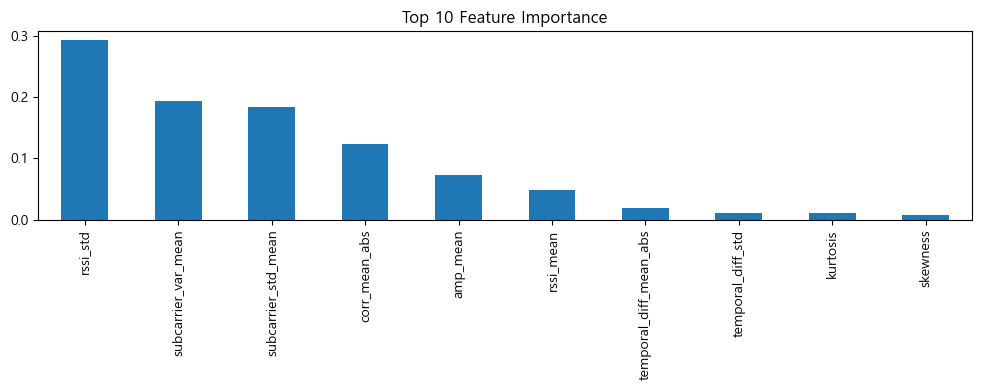

rssi_std                  0.292419
subcarrier_var_mean       0.193140
subcarrier_std_mean       0.182937
corr_mean_abs             0.123281
amp_mean                  0.072323
rssi_mean                 0.048830
temporal_diff_mean_abs    0.019746
temporal_diff_std         0.010897
kurtosis                  0.010763
skewness                  0.007165
dtype: float64


In [35]:
base = getattr(raw_model, 'named_steps', {}).get('svm', raw_model)
if hasattr(base, 'feature_importances_'):
    fi = pd.Series(base.feature_importances_, index=feature_cols).sort_values(ascending=False)
    fi.head(10).plot(kind='bar', figsize=(10, 4), title='Top 10 Feature Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100)
    plt.show()
    print(fi.head(10))
else:
    print('피처 중요도 미지원 모델')

## 7. 모델 저장

In [36]:
import joblib

joblib.dump(calibrated_model, "model.pkl")
joblib.dump(feature_cols,     "feature_cols.pkl")

print("저장 완료: model.pkl")
print("저장 완료: feature_cols.pkl")


저장 완료: model.pkl
저장 완료: feature_cols.pkl
